# AgroScan - Jalon 2 

1. **Augmentation réaliste** : remplace l'augmentation légère de la baseline par des transformations plus fortes (flip vertical, rotations importantes, variations de luminosité, bruit) qui rapprochent PlantVillage des conditions mobiles terrain.
2. **Fine-tuning sur PlantDoc** : après l'entraînement principal sur PlantVillage, une deuxième phase d'entraînement adapte le modèle au domaine réel en dégelant le dernier quart du backbone et en entraînant sur `data/plantdoc/train/` avec un très faible taux d'apprentissage.

## 1. Lancement du notebook avec le GPU

TensorFlow utilise les bibliothèques CUDA/cuDNN installées dans l'environnement `.venv` par `tensorflow[and-cuda]`. Sur certaines machines, ces bibliothèques ne sont pas trouvées automatiquement par le chargeur dynamique Linux.

Pour lancer Jupyter avec les bons chemins GPU, démarrer le serveur depuis la racine du projet avec :

```bash
./scripts/tf_gpu_env.sh uv run jupyter lab
```

Le script définit `LD_LIBRARY_PATH` avant le démarrage du kernel Python.

## 2. Installation et imports

Installer les dépendances depuis la racine du projet :

```bash
uv pip install -r requirements.txt
```

In [1]:
# %pip install -r ../requirements.txt

In [2]:
import shutil
import subprocess
from pathlib import Path
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

import tensorflow as tf
import tensorflow_datasets as tfds

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 3. Configuration du projet

In [3]:
ROOT = Path('..').resolve()
DATA_DIR = ROOT / 'data'
MODEL_DIR = ROOT / 'models'
REPORT_DIR = ROOT / 'reports'

for directory in [DATA_DIR, MODEL_DIR, REPORT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# Phase 1 : entraînement PlantVillage
EPOCHS_PHASE1 = 5

# Phase 2 : fine-tuning PlantDoc
EPOCHS_PHASE2 = 10
LR_PHASE2 = 5e-5       # taux très faible pour préserver les acquis PlantVillage
UNFREEZE_RATIO = 0.75  # fraction du backbone à garder gelée

tf.keras.utils.set_random_seed(SEED)
AUTOTUNE = tf.data.AUTOTUNE

print('Racine projet:', ROOT)

Racine projet: /


## 4. Chargement de PlantVillage et configuration PlantDoc

PlantVillage est chargé comme jeu principal. La table de correspondance PlantDoc→PlantVillage et la vérification du dataset PlantDoc sont faites ici, en début de pipeline, pour disposer de toutes les données avant de construire les datasets.

In [4]:
(train_raw, val_raw, test_raw), info = tfds.load(
    'plant_village',
    split=['train[:70%]', 'train[70%:85%]', 'train[85%:]'],
    as_supervised=True,
    with_info=True,
    data_dir=str(DATA_DIR / 'tfds'),
)

class_names = info.features['label'].names
num_classes = len(class_names)

print('Nombre de classes:', num_classes)
print('Exemples de classes:', class_names[:8])
print(info.splits)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /data/tfds/plant_village/incomplete.HBRPOI_1.0.2/plant_village-train.tfrecord*...:   0%|          | …

Dataset plant_village downloaded and prepared to /data/tfds/plant_village/1.0.2. Subsequent calls will reuse this data.
Nombre de classes: 38
Exemples de classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry___healthy', 'Cherry___Powdery_mildew', 'Corn___Cercospora_leaf_spot Gray_leaf_spot']
{Split('train'): <SplitInfo num_examples=54303, num_shards=8>}


In [5]:
PLANTDOC_DIR = DATA_DIR / 'plantdoc'
PLANTDOC_TEST_DIR  = PLANTDOC_DIR / 'test'
PLANTDOC_TRAIN_DIR = PLANTDOC_DIR / 'train'

# Correspondance manuelle PlantDoc → PlantVillage
plantdoc_to_plantvillage = {
    'Apple Scab Leaf':                        'Apple___Apple_scab',
    'Apple leaf':                             'Apple___healthy',
    'Apple rust leaf':                        'Apple___Cedar_apple_rust',
    'Bell_pepper leaf':                       'Pepper,_bell___healthy',
    'Bell_pepper leaf spot':                  'Pepper,_bell___Bacterial_spot',
    'Blueberry leaf':                         'Blueberry___healthy',
    'Cherry leaf':                            'Cherry___healthy',
    'Corn Gray leaf spot':                    'Corn___Cercospora_leaf_spot Gray_leaf_spot',
    'Corn leaf blight':                       'Corn___Northern_Leaf_Blight',
    'Corn rust leaf':                         'Corn___Common_rust',
    'Peach leaf':                             'Peach___healthy',
    'Potato leaf early blight':               'Potato___Early_blight',
    'Potato leaf late blight':                'Potato___Late_blight',
    'Raspberry leaf':                         'Raspberry___healthy',
    'Soyabean leaf':                          'Soybean___healthy',
    'Squash Powdery mildew leaf':             'Squash___Powdery_mildew',
    'Strawberry leaf':                        'Strawberry___healthy',
    'Tomato Early blight leaf':               'Tomato___Early_blight',
    'Tomato Septoria leaf spot':              'Tomato___Septoria_leaf_spot',
    'Tomato leaf':                            'Tomato___healthy',
    'Tomato leaf bacterial spot':             'Tomato___Bacterial_spot',
    'Tomato leaf late blight':                'Tomato___Late_blight',
    'Tomato leaf mosaic virus':               'Tomato___Tomato_mosaic_virus',
    'Tomato leaf yellow virus':               'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
    'Tomato mold leaf':                       'Tomato___Leaf_Mold',
    'Tomato two spotted spider mites leaf':   'Tomato___Spider_mites Two-spotted_spider_mite',
    'grape leaf':                             'Grape___healthy',
    'grape leaf black rot':                   'Grape___Black_rot',
}

if not PLANTDOC_TEST_DIR.exists():
    print('PlantDoc absent — téléchargement depuis GitHub...')
    PLANTDOC_DIR.mkdir(parents=True, exist_ok=True)
    tmp_clone = DATA_DIR / '_plantdoc_clone'
    subprocess.run(
        ['git', 'clone', '--depth', '1',
         'https://github.com/pratikkayal/PlantDoc-Dataset.git',
         str(tmp_clone)],
        check=True,
    )
    for split in ('train', 'test'):
        clone_src = tmp_clone / split
        clone_dst = PLANTDOC_DIR / split
        if clone_src.exists() and not clone_dst.exists():
            shutil.copytree(clone_src, clone_dst)
    shutil.rmtree(tmp_clone)
    print('PlantDoc téléchargé.')

# Table de correspondance pour l'évaluation (test set)
valid_mapping = {}
if PLANTDOC_TEST_DIR.exists():
    plantdoc_classes = sorted([p.name for p in PLANTDOC_TEST_DIR.iterdir() if p.is_dir()])
    valid_mapping = {
        pd_cls: pv_cls for pd_cls, pv_cls in plantdoc_to_plantvillage.items()
        if pd_cls in plantdoc_classes and pv_cls in class_names
    }
    print(f'PlantDoc test  : {len(plantdoc_classes)} classes, {len(valid_mapping)} évaluables')
else:
    print('PlantDoc non trouvé. Placer le dataset dans data/plantdoc/')

PlantDoc absent — téléchargement depuis GitHub...
PlantDoc téléchargé.
PlantDoc test  : 27 classes, 27 évaluables


## 5. Exploration rapide des données

In [6]:
def count_labels(ds):
    counts = np.zeros(num_classes, dtype=int)
    for _, label in tfds.as_numpy(ds):
        counts[int(label)] += 1
    return counts

train_counts = count_labels(train_raw)
val_counts   = count_labels(val_raw)
test_counts  = count_labels(test_raw)

distribution = pd.DataFrame({
    'classe':     class_names,
    'train':      train_counts,
    'validation': val_counts,
    'test':       test_counts,
})
distribution['total'] = distribution[['train', 'validation', 'test']].sum(axis=1)
distribution.sort_values('total', ascending=False).head(10)

,classe,train,validation,test,total
15,Orange___Haunglongbing_(Citrus_greening),3849,826,832,5507
37,Tomato___Tomato_Yellow_Leaf_Curl_Virus,3700,804,853,5357
24,Soybean___healthy,3572,727,791,5090
16,Peach___Bacterial_spot,1609,345,343,2297
28,Tomato___Bacterial_spot,1534,308,285,2127
31,Tomato___Late_blight,1357,270,281,1908
25,Squash___Powdery_mildew,1251,303,281,1835
33,Tomato___Septoria_leaf_spot,1224,285,262,1771
34,Tomato___Spider_mites Two-spotted_spider_mite,1188,238,250,1676
3,Apple___healthy,1139,251,255,1645


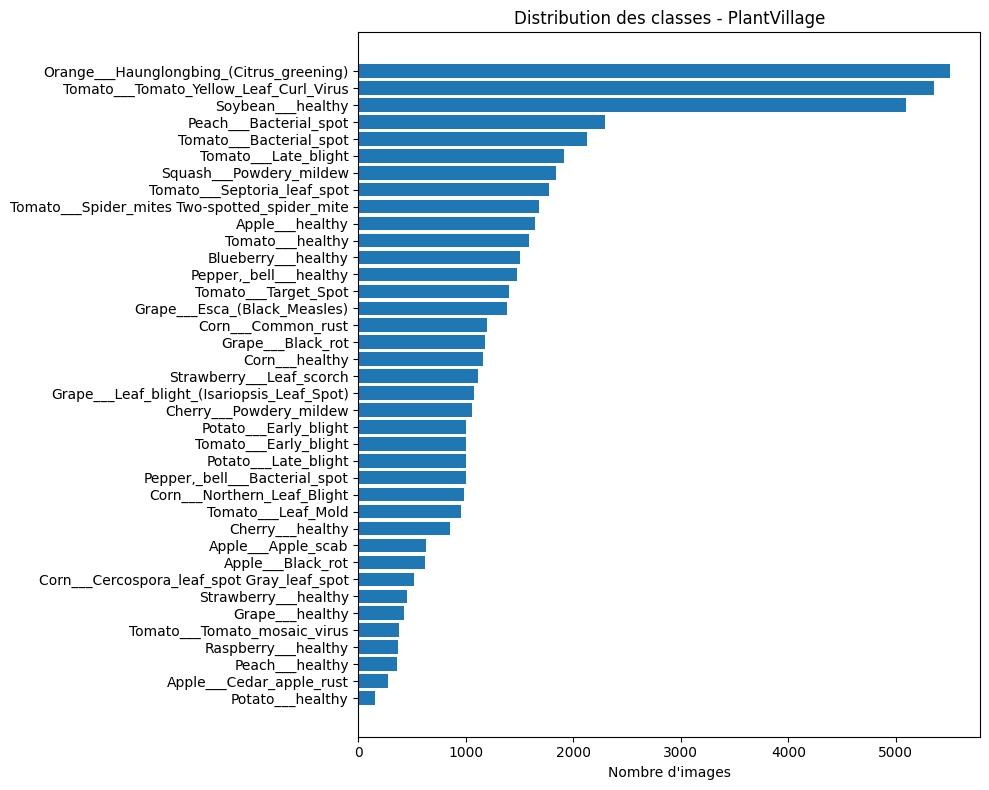

In [7]:
plt.figure(figsize=(10, 8))
plot_df = distribution.sort_values('total', ascending=True)
plt.barh(plot_df['classe'], plot_df['total'])
plt.title('Distribution des classes - PlantVillage')
plt.xlabel("Nombre d'images")
plt.tight_layout()
plt.show()

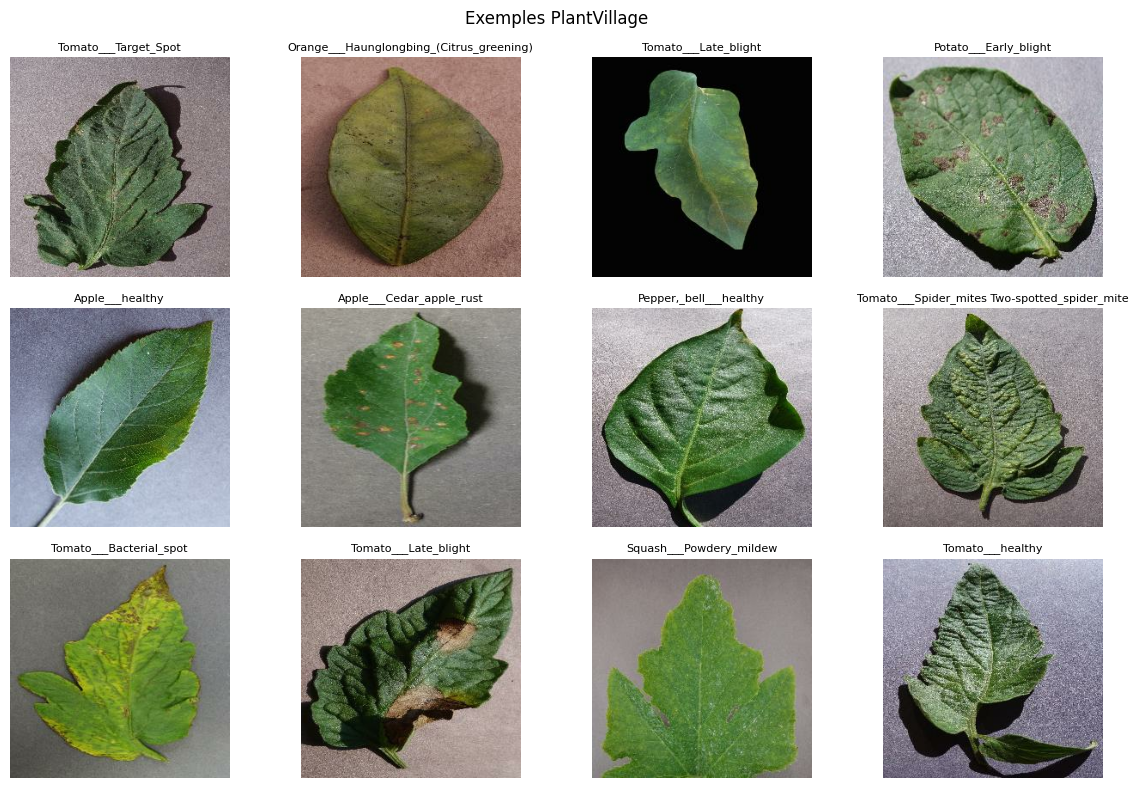

In [8]:
plt.figure(figsize=(12, 8))
for i, (image, label) in enumerate(train_raw.take(12)):
    plt.subplot(3, 4, i + 1)
    plt.imshow(image.numpy())
    plt.title(class_names[int(label)], fontsize=8)
    plt.axis('off')
plt.suptitle('Exemples PlantVillage')
plt.tight_layout()
plt.show()

## 6. Augmentation réaliste et prétraitement

L'augmentation est renforcée par rapport à la baseline pour mieux représenter les conditions de prise de vue mobile : orientations variables (flip vertical inclus), rotation plus forte, zoom-in prononcé, variations de luminosité et de contraste, et bruit capteur. Ces transformations réduisent le gap de domaine entre PlantVillage (studio) et PlantDoc (terrain).

Comme dans la baseline, les images restent en pixels `[0, 255]` car MobileNetV3 est instancié avec `include_preprocessing=True`.

In [10]:
# Augmentation réaliste utilisée pour les deux phases d'entraînement
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal_and_vertical', seed=SEED),
    tf.keras.layers.RandomRotation(0.25, seed=SEED),
    tf.keras.layers.RandomZoom((-0.35, 0.1), seed=SEED),
    tf.keras.layers.RandomContrast(0.4, seed=SEED),
    tf.keras.layers.RandomBrightness(0.2, seed=SEED),
    tf.keras.layers.Lambda(
        lambda x: x + tf.random.normal(tf.shape(x), mean=0.0, stddev=10.0),
        name='gaussian_noise_10',
    ),
], name='data_augmentation_realistic')

def preprocess(image, label, training=False):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    if training:
        image = data_augmentation(image, training=True)
    return image, label

train_ds = (
    train_raw
    .shuffle(4096, seed=SEED, reshuffle_each_iteration=False)
    .map(lambda x, y: preprocess(x, y, training=True), num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
val_ds  = val_raw.map(preprocess,  num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_ds = test_raw.map(preprocess, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)

options = tf.data.Options()
options.deterministic = True
train_ds = train_ds.with_options(options)
val_ds   = val_ds.with_options(options)
test_ds  = test_ds.with_options(options)

## 7. Préparation du dataset PlantDoc pour le fine-tuning

Les images de `data/plantdoc/train/` sont chargées et leurs labels sont remappés vers les indices PlantVillage correspondants. Un split 80/20 est créé pour monitorer la validation pendant la phase 2. La même augmentation réaliste est appliquée.

In [12]:
pv_label_to_idx = {name: idx for idx, name in enumerate(class_names)}

ft_image_paths, ft_image_labels = [], []
for pd_cls, pv_cls in plantdoc_to_plantvillage.items():
    cls_train_dir = PLANTDOC_TRAIN_DIR / pd_cls
    if not cls_train_dir.exists() or pv_cls not in class_names:
        continue
    pv_idx = pv_label_to_idx[pv_cls]
    for p in sorted(cls_train_dir.iterdir()):
        if p.is_file():
            ft_image_paths.append(str(p))
            ft_image_labels.append(pv_idx)

# Mélange reproductible puis split 80 / 20
rng_ft = np.random.default_rng(SEED)
perm = rng_ft.permutation(len(ft_image_paths))
ft_image_paths  = [ft_image_paths[i]  for i in perm]
ft_image_labels = [ft_image_labels[i] for i in perm]

n_val = int(0.2 * len(ft_image_paths))
ft_val_paths,   ft_val_labels   = ft_image_paths[:n_val],  ft_image_labels[:n_val]
ft_train_paths, ft_train_labels = ft_image_paths[n_val:],  ft_image_labels[n_val:]

print(f'PlantDoc fine-tuning — train : {len(ft_train_paths)} images, val : {len(ft_val_paths)} images')
print(f'Classes représentées : {len(set(ft_image_labels))} / {num_classes}')

def load_image_ft(path, label, augment=False):
    raw = tf.io.read_file(path)
    img = tf.image.decode_image(raw, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    if augment:
        img = data_augmentation(img, training=True)
    return img, label

ft_train_ds = (
    tf.data.Dataset.from_tensor_slices((ft_train_paths, ft_train_labels))
    .map(lambda p, l: load_image_ft(p, l, augment=True), num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
ft_val_ds = (
    tf.data.Dataset.from_tensor_slices((ft_val_paths, ft_val_labels))
    .map(load_image_ft, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

PlantDoc fine-tuning — train : 1874 images, val : 468 images
Classes représentées : 28 / 38


## 8. Modèle : MobileNetV3Small

Même architecture que la baseline : MobileNetV3Small avec `include_preprocessing=True`, backbone gelé, tête de classification entraînable. Compatible TFLite pour l'export mobile.

In [13]:
base_model = tf.keras.applications.MobileNetV3Small(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet',
    include_preprocessing=True,
)
base_model.trainable = False

inputs  = tf.keras.Input(shape=IMG_SIZE + (3,))
x       = base_model(inputs, training=False)
x       = tf.keras.layers.GlobalAveragePooling2D()(x)
x       = tf.keras.layers.Dropout(0.25)(x)
outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs, name='agroscan_mobilenetv3_improved')
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

model.summary()

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "agroscan_mobilenetv3_improved"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 38)             │        21,926 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 961,046 (3.67 MB)

 Trainable params: 21,926 (85.65 KB)

 Non-trainable params: 939,120 (3.58 MB)

## 9. Phase 1 — Entraînement sur PlantVillage

Le backbone est entièrement gelé. Seule la tête de classification est entraînée, avec l'augmentation réaliste appliquée dès cette phase. Le meilleur checkpoint est sauvegardé pour servir de point de départ à la phase 2.

> **Résultats obtenus** — 5 epochs complètes (pas d'early-stopping). Meilleure val_accuracy : **90,39 %** (epoch 4). L'accuracy est inférieure à la baseline (~96 %) car l'augmentation forte (flip vertical, rotation 25°, bruit) rend la tâche plus difficile et ralentit la convergence sur PlantVillage.

Epoch 1/5
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 551s 449ms/step - accuracy: 0.7482 - loss: 0.9524 - val_accuracy: 0.8715 - val_loss: 0.4789
Epoch 2/5
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 541s 441ms/step - accuracy: 0.8722 - loss: 0.4395 - val_accuracy: 0.8942 - val_loss: 0.3586
Epoch 3/5
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 526s 442ms/step - accuracy: 0.8937 - loss: 0.3550 - val_accuracy: 0.8969 - val_loss: 0.3311
Epoch 4/5
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 521s 437ms/step - accuracy: 0.9013 - loss: 0.3192 - val_accuracy: 0.9039 - val_loss: 0.2973
Epoch 5/5
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 566s 441ms/step - accuracy: 0.9076 - loss: 0.2953 - val_accuracy: 0.9019 - val_loss: 0.2889


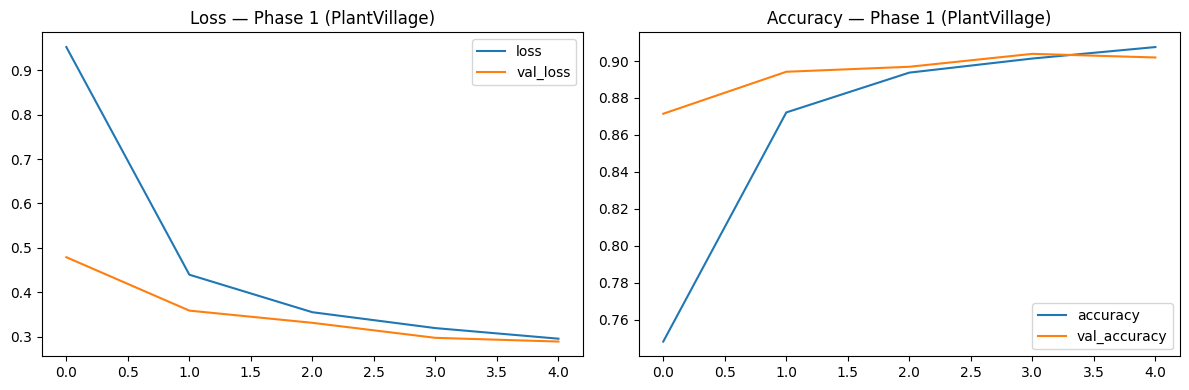

In [14]:
phase1_checkpoint_path = str(MODEL_DIR / 'agroscan_improved_phase1.keras')

callbacks_phase1 = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=phase1_checkpoint_path,
        monitor='val_accuracy',
        save_best_only=True,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=2,
        restore_best_weights=True,
    ),
]

history_p1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE1,
    callbacks=callbacks_phase1,
)

history_p1_df = pd.DataFrame(history_p1.history)
history_p1_df.to_csv(REPORT_DIR / 'improved_phase1_history.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
history_p1_df[['loss', 'val_loss']].plot(ax=axes[0], title='Loss — Phase 1 (PlantVillage)')
history_p1_df[['accuracy', 'val_accuracy']].plot(ax=axes[1], title='Accuracy — Phase 1 (PlantVillage)')
plt.tight_layout()
plt.show()

## 10. Phase 2 — Fine-tuning sur PlantDoc

Le dernier quart des couches du backbone est dégelé pour permettre l'adaptation au domaine terrain, avec un taux d'apprentissage très faible (`5e-5`) pour éviter la catastrophic forgetting. Les couches BatchNormalization restent en mode inférence (statistiques gelées) car le backbone est appelé avec `training=False`.

La validation est faite sur le split PlantDoc val (20 % de `plantdoc/train/`), ce qui permet de suivre la progression sur le domaine cible.

> **Résultats obtenus** — 10 epochs complètes sur 1 874 images train / 468 images val (28 classes). 40 couches dégelées sur 157 (76,6 % des paramètres entraînables, soit 736 238 / 961 046). La val_accuracy a progressé de 20,5 % (epoch 1) à **34 %** (epoch 10), confirmant l'adaptation progressive au domaine terrain.

Backbone : 117/157 couches gelées, 40 dégelerées
Paramètres : 961,046 total, 736,238 entraînables (76.6 %)
Epoch 1/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.1073 - loss: 8.4673 - val_accuracy: 0.2051 - val_loss: 4.6656
Epoch 2/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 53s 778ms/step - accuracy: 0.1318 - loss: 5.7516 - val_accuracy: 0.2372 - val_loss: 3.6430
Epoch 3/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 45s 762ms/step - accuracy: 0.1526 - loss: 4.2666 - val_accuracy: 0.2778 - val_loss: 3.1612
Epoch 4/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 82s 768ms/step - accuracy: 0.1825 - loss: 3.6828 - val_accuracy: 0.2991 - val_loss: 2.9258
Epoch 5/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 47s 806ms/step - accuracy: 0.2188 - loss: 3.2498 - val_accuracy: 0.2949 - val_loss: 2.7831
Epoch 6/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 82s 806ms/step - accuracy: 0.2273 - loss: 3.0639 - val_accuracy: 0.3098 - val_loss: 2.6692
Epoch 7/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 81s 794ms/step - accuracy: 0.2673 - loss: 2.8354 - val_accuracy: 0.3162 - val_loss: 

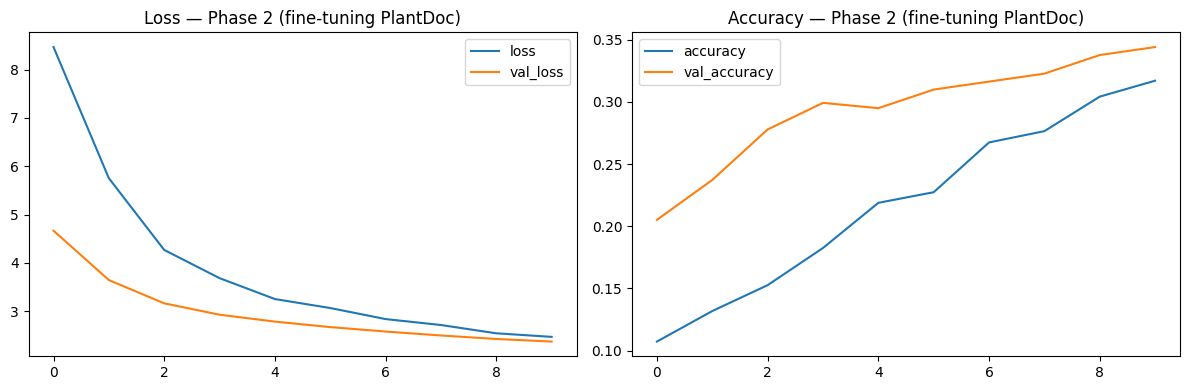

In [15]:
# Dégel partiel du backbone : le dernier quart des couches
backbone = model.layers[1]
n_layers = len(backbone.layers)
freeze_until = int(UNFREEZE_RATIO * n_layers)

backbone.trainable = True
for layer in backbone.layers[:freeze_until]:
    layer.trainable = False

n_trainable = sum(1 for l in backbone.layers if l.trainable)
trainable_params = sum(int(np.prod(w.shape)) for w in model.trainable_weights)
total_params = model.count_params()
print(f'Backbone : {freeze_until}/{n_layers} couches gelées, {n_trainable} dégelerées')
print(f'Paramètres : {total_params:,} total, {trainable_params:,} entraînables ({100 * trainable_params / total_params:.1f} %)')

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_PHASE2),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

phase2_checkpoint_path = str(MODEL_DIR / 'agroscan_improved_phase2.keras')

callbacks_phase2 = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=phase2_checkpoint_path,
        monitor='val_accuracy',
        save_best_only=True,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True,
    ),
]

history_p2 = model.fit(
    ft_train_ds,
    validation_data=ft_val_ds,
    epochs=EPOCHS_PHASE2,
    callbacks=callbacks_phase2,
)

history_p2_df = pd.DataFrame(history_p2.history)
history_p2_df.to_csv(REPORT_DIR / 'improved_phase2_history.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
history_p2_df[['loss', 'val_loss']].plot(ax=axes[0], title='Loss — Phase 2 (fine-tuning PlantDoc)')
history_p2_df[['accuracy', 'val_accuracy']].plot(ax=axes[1], title='Accuracy — Phase 2 (fine-tuning PlantDoc)')
plt.tight_layout()
plt.show()

## 11. Évaluation sur PlantVillage test

> **Note** : l'accuracy sur PlantVillage est attendue inférieure à la baseline. L'augmentation réaliste (rotations fortes, flip vertical, bruit) rend les images d'entraînement beaucoup plus difficiles que les images de test studio de PlantVillage. Le modèle a appris une représentation plus robuste mais moins spécialisée — ce compromis se voit dans les métriques PlantDoc (section 12).

In [16]:
def collect_predictions(model, ds):
    y_true, y_pred, y_proba = [], [], []
    for images, labels in ds:
        proba = model.predict(images, verbose=0)
        y_true.extend(labels.numpy().tolist())
        y_pred.extend(np.argmax(proba, axis=1).tolist())
        y_proba.extend(np.max(proba, axis=1).tolist())
    return np.array(y_true), np.array(y_pred), np.array(y_proba)

y_true_pv, y_pred_pv, y_conf_pv = collect_predictions(model, test_ds)

pv_accuracy = accuracy_score(y_true_pv, y_pred_pv)
pv_f1_macro = f1_score(y_true_pv, y_pred_pv, average='macro')

print(f'PlantVillage — Accuracy : {pv_accuracy:.4f}  |  F1 macro : {pv_f1_macro:.4f}')

PlantVillage — Accuracy : 0.7134  |  F1 macro : 0.6302


In [17]:
report_pv = classification_report(
    y_true_pv, y_pred_pv,
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)
report_pv_df = pd.DataFrame(report_pv).transpose()
report_pv_df.to_csv(REPORT_DIR / 'improved_pv_classification_report.csv')
report_pv_df.head()

,precision,recall,f1-score,support
Apple___Apple_scab,0.691589,0.770833,0.729064,96.0
Apple___Black_rot,1.000000,0.327103,0.492958,107.0
Apple___Cedar_apple_rust,0.486486,0.900000,0.631579,40.0
Apple___healthy,0.450980,0.992157,0.620098,255.0
Blueberry___healthy,0.794677,0.981221,0.878151,213.0


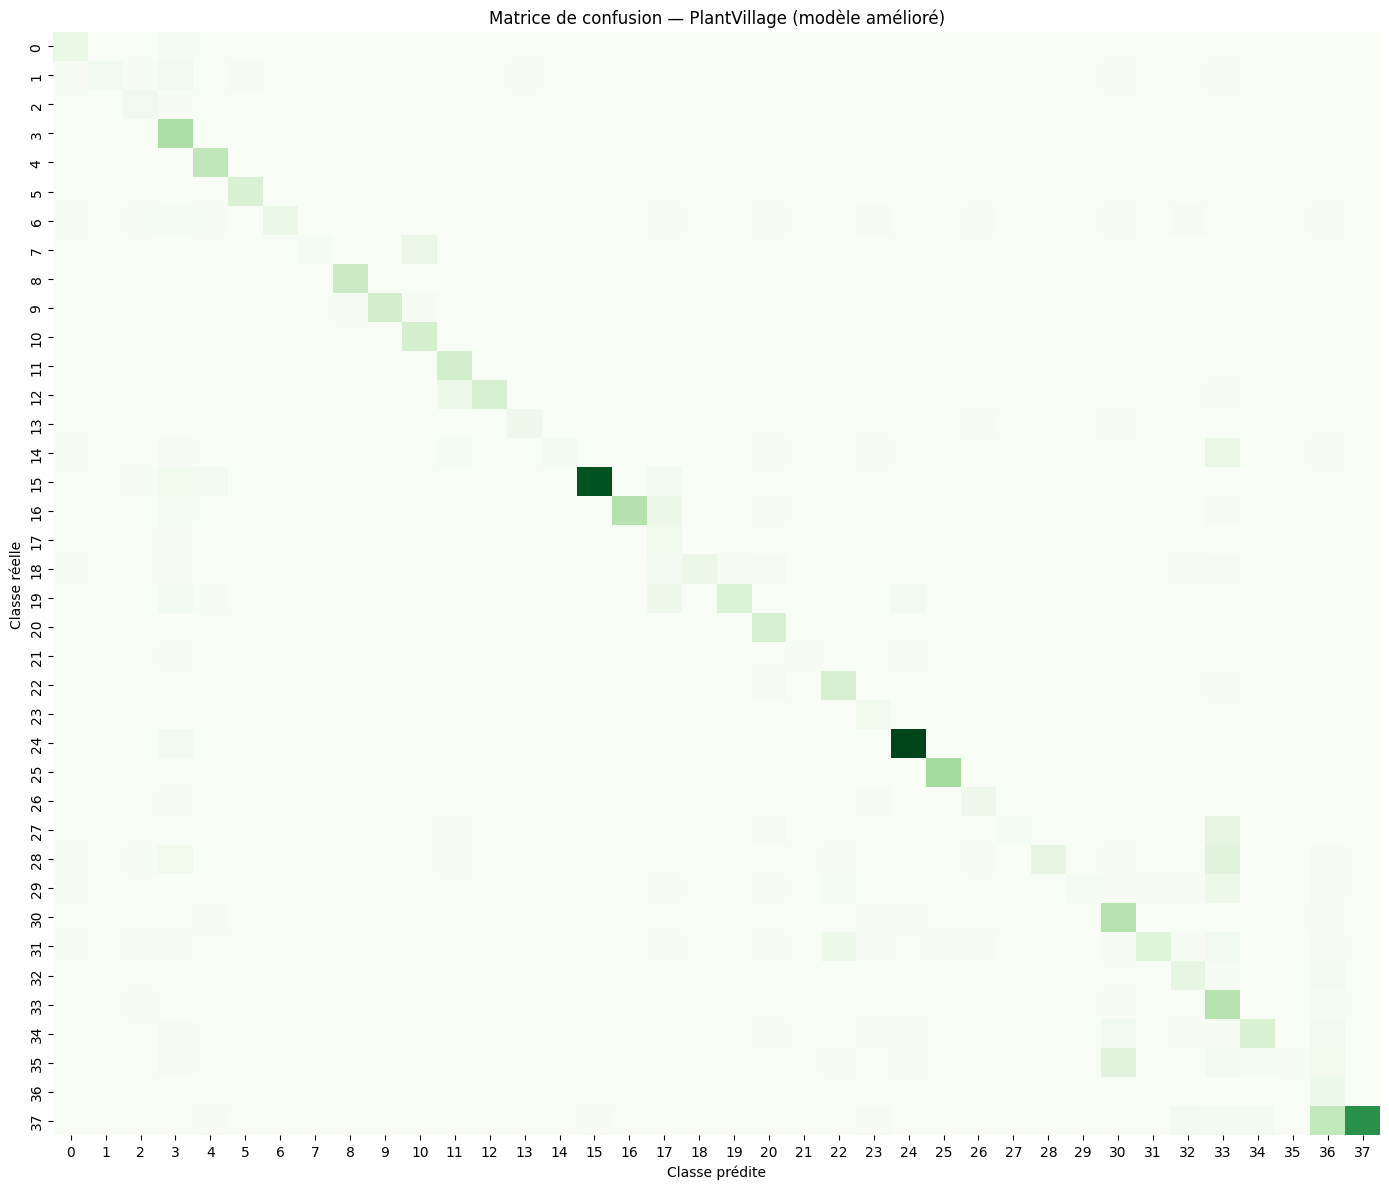

In [18]:
cm = confusion_matrix(y_true_pv, y_pred_pv)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, cmap='Greens', cbar=False)
plt.title('Matrice de confusion — PlantVillage (modèle amélioré)')
plt.xlabel('Classe prédite')
plt.ylabel('Classe réelle')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'improved_confusion_matrix.png', dpi=180)
plt.show()

## 12. Évaluation sur PlantDoc test

PlantDoc est la métrique principale de robustesse terrain. On compare ici directement les résultats du modèle amélioré avec ceux de la baseline.

> **Résultats obtenus** — 236 images évaluées, 27 classes. Accuracy **+14,41 pp** (22,88 % → 37,29 %) et F1 macro **+13,80 pp** (17,39 % → 31,19 %). La confiance moyenne baisse (63,37 % → 42,16 %), ce qui est un signal positif : le modèle est moins sur-confiant sur des images hors distribution.

In [19]:
plantdoc_test = tf.keras.utils.image_dataset_from_directory(
    PLANTDOC_TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

plantdoc_class_names = plantdoc_test.class_names
pd_label_to_pv_index = {
    plantdoc_class_names.index(pd_label): pv_label_to_idx[pv_label]
    for pd_label, pv_label in valid_mapping.items()
}

y_true_pd, y_pred_pd, conf_pd = [], [], []

for images, labels in plantdoc_test:
    probs = model.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)
    confs = np.max(probs, axis=1)
    for pd_idx, pred_idx, conf in zip(labels.numpy(), preds, confs):
        pd_idx = int(pd_idx)
        if pd_idx not in pd_label_to_pv_index:
            continue
        y_true_pd.append(pd_label_to_pv_index[pd_idx])
        y_pred_pd.append(int(pred_idx))
        conf_pd.append(float(conf))

y_true_pd = np.array(y_true_pd)
y_pred_pd = np.array(y_pred_pd)
conf_pd   = np.array(conf_pd)

pd_accuracy = accuracy_score(y_true_pd, y_pred_pd)
pd_f1_macro = f1_score(y_true_pd, y_pred_pd, average='macro')

print(f'Images évaluées : {len(y_true_pd)} | Classes : {len(valid_mapping)}')
print()
# Référence baseline (jalon2_pipeline_baseline.ipynb)
print(f'{"":18s}  {"Accuracy":>10s}  {"F1 macro":>10s}  {"Conf. moy.":>10s}')
print(f'{"Baseline":18s}  {0.2288:>10.4f}  {0.1739:>10.4f}  {0.6337:>10.4f}')
print(f'{"Modèle amélioré":18s}  {pd_accuracy:>10.4f}  {pd_f1_macro:>10.4f}  {conf_pd.mean():>10.4f}')

Found 236 files belonging to 27 classes.
Images évaluées : 236 | Classes : 27

                      Accuracy    F1 macro  Conf. moy.
Baseline                0.2288      0.1739      0.6337
Modèle amélioré         0.3729      0.3119      0.4216


In [20]:
common_labels = sorted(set(y_true_pd))
report_pd_df = pd.DataFrame(
    classification_report(
        y_true_pd, y_pred_pd,
        labels=common_labels,
        target_names=[class_names[i] for i in common_labels],
        output_dict=True,
        zero_division=0,
    )
).T
report_pd_df.to_csv(REPORT_DIR / 'improved_plantdoc_report.csv')
display(report_pd_df.sort_values('f1-score').head(12))
print('Rapport PlantDoc :', REPORT_DIR / 'improved_plantdoc_report.csv')

,precision,recall,f1-score,support
Cherry___healthy,0.000000,0.000000,0.000000,10.0
Tomato___Leaf_Mold,0.000000,0.000000,0.000000,6.0
Tomato___Tomato_mosaic_virus,0.000000,0.000000,0.000000,10.0
Apple___Apple_scab,0.111111,0.100000,0.105263,10.0
Blueberry___healthy,0.166667,0.090909,0.117647,11.0
Tomato___Bacterial_spot,0.142857,0.111111,0.125000,9.0
Tomato___Late_blight,0.333333,0.100000,0.153846,10.0
Peach___healthy,0.500000,0.111111,0.181818,9.0
Potato___Early_blight,0.153846,0.250000,0.190476,8.0
Potato___Late_blight,0.166667,0.250000,0.200000,8.0


Rapport PlantDoc : /reports/improved_plantdoc_report.csv


## 13. Analyse des erreurs

In [21]:
errors = pd.DataFrame({
    'true_id':    y_true_pv,
    'pred_id':    y_pred_pv,
    'confidence': y_conf_pv,
})
errors['true_class'] = errors['true_id'].map(lambda i: class_names[i])
errors['pred_class'] = errors['pred_id'].map(lambda i: class_names[i])
errors = errors[errors['true_id'] != errors['pred_id']]

print('Nombre d erreurs PlantVillage:', len(errors))
errors.sort_values('confidence', ascending=False).head(15)

Nombre d erreurs PlantVillage: 2334


,true_id,pred_id,confidence,true_class,pred_class
7181,7,10,0.986497,Corn___Cercospora_leaf_spot Gray_leaf_spot,Corn___Northern_Leaf_Blight
577,16,17,0.984070,Peach___Bacterial_spot,Peach___healthy
3434,7,10,0.981408,Corn___Cercospora_leaf_spot Gray_leaf_spot,Corn___Northern_Leaf_Blight
5984,10,8,0.966757,Corn___Northern_Leaf_Blight,Corn___Common_rust
3605,16,17,0.964201,Peach___Bacterial_spot,Peach___healthy
7318,16,17,0.959047,Peach___Bacterial_spot,Peach___healthy
7120,7,10,0.958942,Corn___Cercospora_leaf_spot Gray_leaf_spot,Corn___Northern_Leaf_Blight
5966,7,10,0.955454,Corn___Cercospora_leaf_spot Gray_leaf_spot,Corn___Northern_Leaf_Blight
2141,7,10,0.951619,Corn___Cercospora_leaf_spot Gray_leaf_spot,Corn___Northern_Leaf_Blight
4312,7,10,0.949187,Corn___Cercospora_leaf_spot Gray_leaf_spot,Corn___Northern_Leaf_Blight


## 14. Temps d'inférence

In [22]:
sample_batch = next(iter(test_ds))[0]
_ = model.predict(sample_batch, verbose=0)  # warmup

n_runs = 30
start = time.perf_counter()
for _ in range(n_runs):
    _ = model.predict(sample_batch, verbose=0)
elapsed = time.perf_counter() - start

ms_per_image = (elapsed / (n_runs * sample_batch.shape[0])) * 1000
print(f'Temps moyen CPU/GPU local: {ms_per_image:.2f} ms/image')

Temps moyen CPU/GPU local: 2.62 ms/image


## 15. Visualisation Grad-CAM

Dernière couche convolutionnelle: conv_1


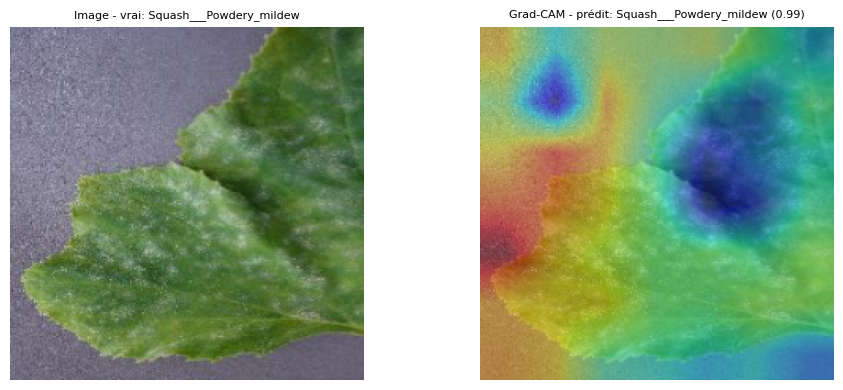

In [23]:
def find_last_conv_layer(model):
    for layer in reversed(model.layers[1].layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError('Aucune couche Conv2D trouvée')

last_conv_layer_name = find_last_conv_layer(model)
print('Dernière couche convolutionnelle:', last_conv_layer_name)

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    base = model.layers[1]
    grad_model = tf.keras.Model(
        inputs=base.input,
        outputs=[base.get_layer(last_conv_layer_name).output, base.output],
    )
    with tf.GradientTape() as tape:
        conv_outputs, features = grad_model(img_array)
        x = model.layers[2](features)
        x = model.layers[3](x, training=False)
        predictions = model.layers[4](x)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

raw_image, raw_label = next(iter(test_raw.take(1)))
display_image = tf.image.resize(raw_image, IMG_SIZE).numpy().astype('uint8')
processed_image, _ = preprocess(raw_image, raw_label)
img_array = tf.expand_dims(processed_image, axis=0)

pred = model.predict(img_array, verbose=0)[0]
pred_id = int(np.argmax(pred))
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_id)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(display_image)
plt.title(f'Image - vrai: {class_names[int(raw_label)]}', fontsize=8)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(display_image)
plt.imshow(tf.image.resize(heatmap[..., None], IMG_SIZE).numpy().squeeze(), cmap='jet', alpha=0.45)
plt.title(f'Grad-CAM - prédit: {class_names[pred_id]} ({pred[pred_id]:.2f})', fontsize=8)
plt.axis('off')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'improved_gradcam_example.png', dpi=180)
plt.show()

## 16. Export TFLite

Le modèle final (après fine-tuning PlantDoc) est exporté en TFLite avec quantification dynamique.

In [24]:
keras_model_path = MODEL_DIR / 'agroscan_improved.keras'
model.save(str(keras_model_path))
print('Modèle Keras sauvegardé :', keras_model_path)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

tflite_path = MODEL_DIR / 'agroscan_improved_dynamic_quant.tflite'
tflite_path.write_bytes(tflite_model)

labels_path = MODEL_DIR / 'labels.json'
labels_path.write_text(json.dumps(class_names, ensure_ascii=False, indent=2), encoding='utf-8')

print('TFLite :', tflite_path, f'({tflite_path.stat().st_size / 1024 / 1024:.2f} Mo)')
print('Labels :', labels_path)

Modèle Keras sauvegardé : /models/agroscan_improved.keras
Saved artifact at '/tmp/tmpzuh8t7n3'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_184')
Output Type:
  TensorSpec(shape=(None, 38), dtype=tf.float32, name=None)
Captures:
  134246005828176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134246005829520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134246005829712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134246005828560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134246005827984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134246005826448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134246005829328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134246005828368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134246005828752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134246005830672: Tens

## 17. Synthèse

Ce notebook implémente un pipeline en deux phases pour améliorer la robustesse terrain du modèle AgroScan.

### Pipeline d'entraînement

| Phase | Données | Backbone | LR | Epochs réalisées |
|---|---|---|---|---|
| 1 — PlantVillage | 37 973 images train, augmentation réaliste | Gelé (0 % entraînable) | 1e-3 | 5 (meilleure val_acc : 90,39 %) |
| 2 — PlantDoc FT | 1 874 images train / 468 val, augmentation réaliste | 25 % dégelé (76,6 % params entraînables) | 5e-5 | 10 (val_acc finale : ~34 %) |

### Résultats

| Métrique | Baseline | Modèle amélioré | Delta |
|---|---|---|---|
| PlantVillage — Accuracy | 94,98 % | **71,34 %** | −23,64 pp |
| PlantVillage — F1 macro | 93,63 % | **63,02 %** | −30,61 pp |
| PlantDoc — Accuracy | 22,88 % | **37,29 %** | **+14,41 pp** |
| PlantDoc — F1 macro | 17,39 % | **31,19 %** | **+13,80 pp** |
| Confiance moy. PlantDoc | 63,37 % | **42,16 %** | −21,21 pp |
| Temps d'inférence | — | **2,62 ms/image** | — |

